Diabetes 30-Day Readmission


In [51]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
pd.pandas.set_option('display.max_columns', None)

df = pd.read_csv("diabetic_data.csv")
ids_map = pd.read_csv("IDS_mapping.csv")
print(df.shape)


(101766, 50)


In [52]:
#Standardizing missing value
df = df.replace('?', np.nan)
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(10))


weight               96.858479
max_glu_serum        94.746772
A1Cresult            83.277322
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
patient_nbr           0.000000
dtype: float64


In [53]:
#Dropping missing columns
df = df.drop(columns=['weight','payer_code','medical_specialty'])
print(df.shape)


(101766, 47)


In [54]:
if 'encounter_id' in df.columns:
    df = df.drop(columns=['encounter_id'])
print('There are', df['patient_nbr'].nunique(), 'unique patients out of a total of', len(df), 'rows.')

There are 71518 unique patients out of a total of 101766 rows.


In [55]:
df['race'] = df['race'].fillna(df['race'].mode()[0])
df['gender'] = df['gender'].replace('Unknown/Invalid', np.nan)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
print(df['race'].value_counts())
print(df['gender'].value_counts())


race
Caucasian          78372
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
gender
Female    54711
Male      47055
Name: count, dtype: int64


In [56]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
age_encoded = ohe.fit_transform(df[['age']])

age_df = pd.DataFrame(age_encoded, columns=ohe.get_feature_names_out(['age']))
df = pd.concat([df.drop(columns=['age']), age_df], axis=1)

In [57]:
df['admission_type_id'] = df['admission_type_id'].replace({
    1:'Emergency', 2:'Urgent', 7:'Trauma Center',
    5:'Not Available', 6:'Not Available', 8:'Not Available',
    3:'Elective', 4:'Newborn'})

#Dropping newborn admissions
before = len(df)
df = df[df['admission_type_id'] != 'Newborn']
df['admission_type_id'].value_counts()


,count
admission_type_id,
Emergency,53990
Elective,18869
Urgent,18480
Not Available,10396
Trauma Center,21


In [58]:
exclude_codes = [11, 13, 14, 19, 20, 21]  # expired or hospice -- confirmed against IDS_mapping.csv
before = len(df)
df = df[~df['discharge_disposition_id'].isin(exclude_codes)]

#Dropping deceased/hospice
def map_discharge(code):
    if code == 1: return 'Home'
    if code in [6, 8]: return 'Home_with_care'
    if code in [2, 3, 4, 5, 9, 10, 15, 22, 23, 24, 27, 28, 29, 30]: return 'Transferred_facility'
    if code == 7: return 'Left_AMA'
    return 'Other'

df['discharge_disposition_id'] = df['discharge_disposition_id'].apply(map_discharge)
df['discharge_disposition_id'].value_counts()


,count
discharge_disposition_id,
Home,60228
Transferred_facility,20768
Home_with_care,13006
Other,4708
Left_AMA,623


In [59]:
def map_admission_source(code):
    if code in [1, 2, 3]: return 'Referral'
    if code in [4, 5, 6, 10, 18, 22, 25, 26]: return 'Transfer'
    if code == 7: return 'Emergency'
    if code in [11, 12, 13, 14, 23, 24]: return 'Delivery_Birth'
    return 'Other'

df['admission_source_id'] = df['admission_source_id'].apply(map_admission_source)
df['admission_source_id'].value_counts()


,count
admission_source_id,
Emergency,55848
Referral,30432
Other,6869
Transfer,6180
Delivery_Birth,4


In [60]:
def map_diag(code):
    if pd.isna(code):
        return 'Missing'
    try:
        code = float(code)
    except ValueError:
        return 'Other'   # V- and E- codes (external causes / supplementary classification)
    if 390 <= code <= 459 or code == 785: return 'Circulatory'
    if 460 <= code <= 519 or code == 786: return 'Respiratory'
    if 520 <= code <= 579 or code == 787: return 'Digestive'
    if 250 <= code < 251: return 'Diabetes'
    if 800 <= code <= 999: return 'Injury'
    if 710 <= code <= 739: return 'Musculoskeletal'
    if 580 <= code <= 629 or code == 788: return 'Genitourinary'
    if 140 <= code <= 239: return 'Neoplasms'
    if 240 <= code <= 279: return 'Endocrine_other'
    return 'Other'

for c in ['diag_1', 'diag_2', 'diag_3']:
    df[c + '_group'] = df[c].apply(map_diag)

df = df.drop(columns=['diag_1', 'diag_2', 'diag_3'])
df['diag_1_group'].value_counts()


,count
diag_1_group,
Circulatory,29678
Other,15150
Respiratory,13932
Digestive,9332
Diabetes,8660
Injury,6852
Genitourinary,5002
Musculoskeletal,4934
Neoplasms,3131


In [61]:
df['service_utilization'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']
df[['number_outpatient','number_emergency','number_inpatient','service_utilization']].describe()


,number_outpatient,number_emergency,number_inpatient,service_utilization
count,99333.000000,99333.000000,99333.000000,99333.000000
mean,0.369253,0.198464,0.630989,1.198705
std,1.265174,0.937779,1.260477,2.294298
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000,2.000000
max,42.000000,76.000000,21.000000,80.000000


In [62]:
df['max_glu_serum'] = df['max_glu_serum'].map({'Norm':1, '>200':2, '>300':3}).fillna(0)
df['A1Cresult'] = df['A1Cresult'].map({'Norm':1, '>7':2, '>8':3}).fillna(0)
print(df['max_glu_serum'].value_counts())
print(df['A1Cresult'].value_counts())


max_glu_serum
0.0    94181
1.0     2545
2.0     1419
3.0     1188
Name: count, dtype: int64
A1Cresult
0.0    82501
3.0     8137
1.0     4922
2.0     3773
Name: count, dtype: int64


In [63]:
df['gender'] = df['gender'].map({'Female':0, 'Male':1})
df['change'] = df['change'].map({'No':0, 'Ch':1})
df['diabetesMed'] = df['diabetesMed'].map({'No':0, 'Yes':1})


In [64]:
near_constant = ['examide','citoglipton','acetohexamide','glimepiride-pioglitazone',
                  'metformin-rosiglitazone','metformin-pioglitazone','troglitazone',
                  'tolbutamide','glipizide-metformin']
df = df.drop(columns=near_constant)

drug_cols = ['metformin','repaglinide','nateglinide','chlorpropamide','glimepiride',
             'glipizide','glyburide','pioglitazone','rosiglitazone','acarbose',
             'miglitol','tolazamide','insulin','glyburide-metformin']
ordinal_map = {'No':0, 'Down':1, 'Steady':2, 'Up':3}
for c in drug_cols:
    df[c] = df[c].map(ordinal_map)

print(df[drug_cols].describe().T[['mean','std']])


                         mean       std
metformin            0.404448  0.819542
repaglinide          0.031208  0.253459
nateglinide          0.014003  0.168597
chlorpropamide       0.001762  0.060758
glimepiride          0.104427  0.453599
glipizide            0.254477  0.679528
glyburide            0.214299  0.633429
pioglitazone         0.147192  0.527721
rosiglitazone        0.127792  0.493523
acarbose             0.006211  0.112500
miglitol             0.000735  0.038462
tolazamide           0.000795  0.040252
insulin              1.056990  1.099399
glyburide-metformin  0.014054  0.167605


In [65]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30'].value_counts())
print('Positive rate:', df['readmitted_30'].mean().round(4))


readmitted_30
0    88020
1    11313
Name: count, dtype: int64
Positive rate: 0.1139


In [66]:
df.shape
print('\nRemaining non-numeric columns')
print(df.select_dtypes(include='object').columns.tolist())

print('\nMissing values left:')
print(df.isnull().sum()[df.isnull().sum() > 0])

df.to_pickle('cleaned_diabetic_data.pkl')


Remaining non-numeric columns
['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'readmitted', 'diag_1_group', 'diag_2_group', 'diag_3_group']

Missing values left:
Series([], dtype: int64)


In [67]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, pointbiserialr

df = pd.read_pickle('cleaned_diabetic_data.pkl')
target = 'readmitted_30'

exclude_from_analysis = ['patient_nbr', 'readmitted', target]

cat_cols = [c for c in df.select_dtypes(include='object').columns if c not in exclude_from_analysis]
num_cols = [c for c in df.select_dtypes(include=['int64','float64']).columns if c not in exclude_from_analysis]

print('Categorical columns being tested:', cat_cols)
print('Numeric columns being tested:', num_cols)


Categorical columns being tested: ['race', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Numeric columns being tested: ['gender', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'tolazamide', 'insulin', 'glyburide-metformin', 'change', 'diabetesMed', 'age_[0-10)', 'age_[10-20)', 'age_[20-30)', 'age_[30-40)', 'age_[40-50)', 'age_[50-60)', 'age_[60-70)', 'age_[70-80)', 'age_[80-90)', 'age_[90-100)', 'service_utilization']


In [68]:
#Categorical features vs. target
results_cat = []
for c in cat_cols:
    table = pd.crosstab(df[c], df[target])
    chi2, p, dof, exp = chi2_contingency(table)
    n = table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    results_cat.append((c, p, cramers_v))

res_cat_df = pd.DataFrame(results_cat, columns=['feature','p_value','cramers_v'])
res_cat_df = res_cat_df.sort_values('cramers_v', ascending=False).reset_index(drop=True)
res_cat_df


,feature,p_value,cramers_v
0,discharge_disposition_id,3.456794e-175,0.090605
1,diag_3_group,1.990257e-24,0.037098
2,diag_1_group,2.793406e-14,0.029488
3,diag_2_group,1.188898e-11,0.027100
4,admission_source_id,1.695129e-09,0.021701
5,admission_type_id,4.954051e-06,0.017371
6,race,1.879132e-01,0.007871


In [69]:
#Numeric features vs. target
results_num = []
for c in num_cols:
    r, p = pointbiserialr(df[target], df[c])
    results_num.append((c, p, r))

res_num_df = pd.DataFrame(results_num, columns=['feature','p_value','correlation'])
res_num_df['abs_corr'] = res_num_df['correlation'].abs()
res_num_df = res_num_df.sort_values('abs_corr', ascending=False).drop(columns='abs_corr').reset_index(drop=True)
res_num_df


,feature,p_value,correlation
0,number_inpatient,0.000000e+00,0.168337
1,service_utilization,0.000000e+00,0.127946
2,number_emergency,3.210450e-82,0.060887
3,number_diagnoses,5.369996e-64,0.053551
4,time_in_hospital,1.712437e-49,0.046900
5,num_medications,1.396699e-38,0.041198
6,insulin,1.391227e-18,0.027910
7,metformin,1.087612e-16,-0.026314
8,diabetesMed,2.840364e-16,0.025950
9,num_lab_procedures,3.365251e-14,0.024058


In [70]:
drop_weak = ['race', 'gender', 'tolazamide', 'miglitol', 'glipizide',
             'glyburide-metformin', 'nateglinide', 'acarbose', 'chlorpropamide']

df_model = df.drop(columns=drop_weak)
print('Dropped (negligible effect size, non-significant):', drop_weak)
print('Remaining shape:', df_model.shape)


Dropped (negligible effect size, non-significant): ['race', 'gender', 'tolazamide', 'miglitol', 'glipizide', 'glyburide-metformin', 'nateglinide', 'acarbose', 'chlorpropamide']
Remaining shape: (99333, 39)


In [71]:
from sklearn.preprocessing import OneHotEncoder

cat_cols_remaining = df_model.select_dtypes(include='object').columns.tolist()
cat_cols_remaining = [c for c in cat_cols_remaining if c != 'readmitted']
print('One-hot encoding:', cat_cols_remaining)

ohe2 = OneHotEncoder(drop='first', sparse_output=False)
encoded_array = ohe2.fit_transform(df_model[cat_cols_remaining])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe2.get_feature_names_out(cat_cols_remaining),
    index=df_model.index
)

df_encoded = pd.concat([df_model.drop(columns=cat_cols_remaining), encoded_df], axis=1)
df_encoded = df_encoded.drop(columns=['readmitted'])
print('Final feature matrix shape (including patient_nbr and target):', df_encoded.shape)

One-hot encoding: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Final feature matrix shape (including patient_nbr and target): (99333, 74)


In [72]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df_encoded['patient_nbr']
train_idx, test_idx = next(gss.split(df_encoded, groups=groups))

train_df = df_encoded.iloc[train_idx]
test_df = df_encoded.iloc[test_idx]

overlap = set(train_df['patient_nbr']) & set(test_df['patient_nbr'])
print('Patient overlap between train and test (must be 0):', len(overlap))

target = 'readmitted_30'
X_train = train_df.drop(columns=['patient_nbr', target])
y_train = train_df[target]
X_test = test_df.drop(columns=['patient_nbr', target])
y_test = test_df[target]

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train positive rate: %.4f   Test positive rate: %.4f' % (y_train.mean(), y_test.mean()))


Patient overlap between train and test (must be 0): 0
Train shape: (79434, 72)  Test shape: (19899, 72)
Train positive rate: 0.1146   Test positive rate: 0.1109


Training Models

In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report, confusion_matrix

results = {}

# Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(class_weight='balanced', max_iter=2000)
log_reg.fit(X_train_scaled, y_train)
proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
results['LogReg'] = (roc_auc_score(y_test, proba_lr), average_precision_score(y_test, proba_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
results['RandomForest'] = (roc_auc_score(y_test, proba_rf), average_precision_score(y_test, proba_rf))

# XGBoost
# Sanitize column names for XGBoost
X_train.columns = X_train.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)
X_test.columns = X_test.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace('<', '_', regex=False)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(scale_pos_weight=neg/pos, eval_metric='logloss',
                               max_depth=5, n_estimators=200, learning_rate=0.1,
                               random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
results['XGBoost'] = (roc_auc_score(y_test, proba_xgb), average_precision_score(y_test, proba_xgb))

print('Model comparison:')
print(f"{'Model':15s} {'AUC':>8s} {'PR-AUC':>8s}")
for k, v in results.items():
    print(f"{k:15s} {v[0]:8.4f} {v[1]:8.4f}")

Model comparison:
Model                AUC   PR-AUC
LogReg            0.6581   0.2076
RandomForest      0.6551   0.1912
XGBoost           0.6577   0.2033


In [74]:
best_proba = proba_xgb
best_model = xgb_model

print(classification_report(y_test, (best_proba > 0.5).astype(int)))
print('Confusion matrix (threshold = 0.5):')
print(confusion_matrix(y_test, (best_proba > 0.5).astype(int)))


              precision    recall  f1-score   support

           0       0.93      0.67      0.78     17693
           1       0.18      0.57      0.27      2206

    accuracy                           0.66     19899
   macro avg       0.55      0.62      0.52     19899
weighted avg       0.84      0.66      0.72     19899

Confusion matrix (threshold = 0.5):
[[11846  5847]
 [  957  1249]]


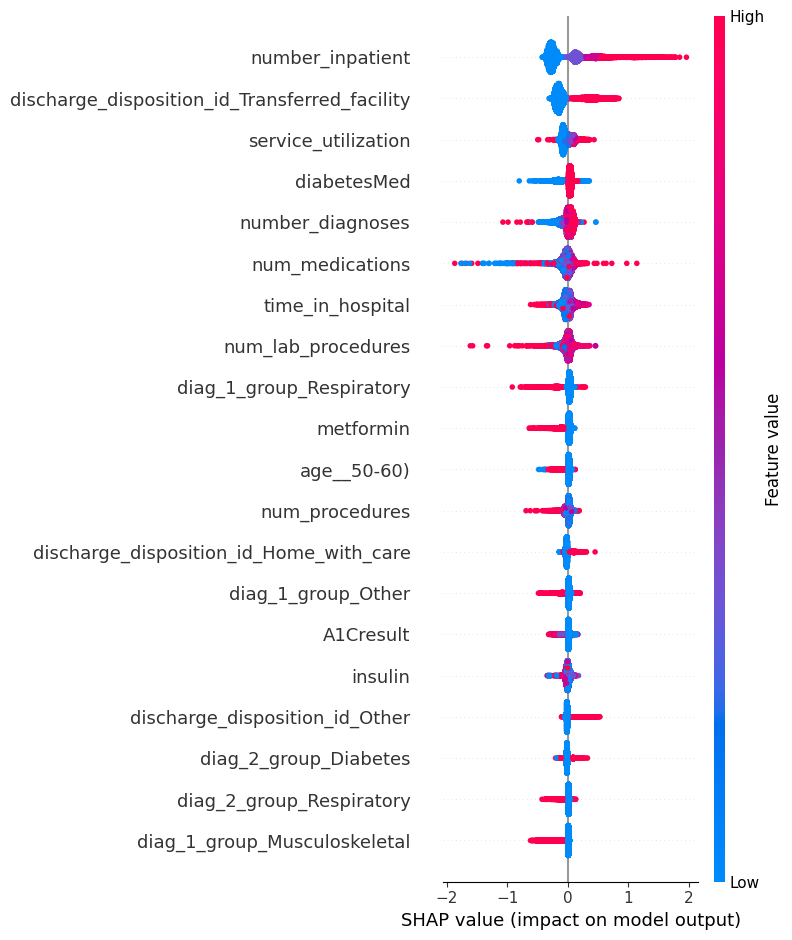

In [75]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


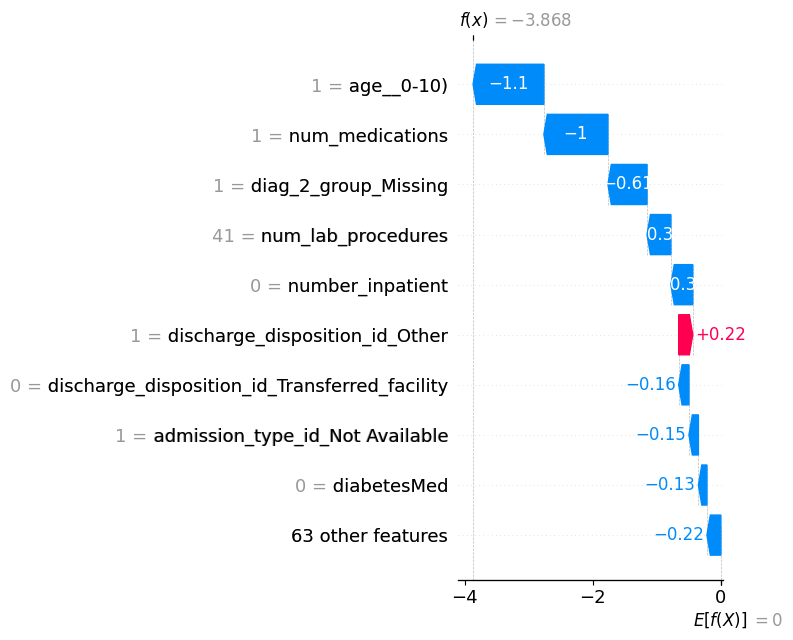

In [76]:
shap.plots.waterfall(shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_test.iloc[0],
    feature_names=X_test.columns.tolist()
), show=False)
plt.tight_layout()
plt.show()


In [77]:
# LinearExplainer is the correct SHAP explainer for linear models
# We pass scaled data because LogReg was trained on scaled features

# Use a background sample of 500 rows for efficiency
background_lr = shap.sample(X_train_scaled, 500, random_state=42)
explainer_lr  = shap.LinearExplainer(log_reg, background_lr)

# Compute SHAP values on test set (use sample for speed)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
shap_values_lr   = explainer_lr.shap_values(X_test_scaled_df)

print('SHAP values computed for Logistic Regression.')
print(f'Shape: {shap_values_lr.shape}  (rows x features)')

SHAP values computed for Logistic Regression.
Shape: (19899, 72)  (rows x features)


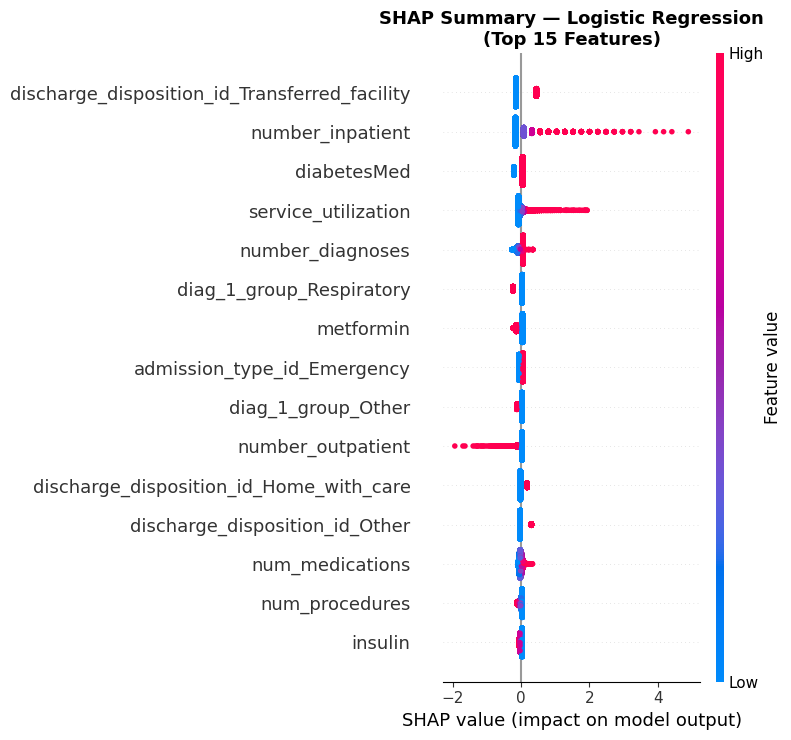

Saved: shap_logreg_summary.png


In [78]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values_lr,
    X_test_scaled_df,
    plot_type='dot',       # beeswarm — shows distribution + direction
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Logistic Regression\n(Top 15 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_logreg_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_logreg_summary.png')

In [80]:
explainer_rf = shap.TreeExplainer(rf)

X_test_sample = X_test.sample(1000, random_state=42)
shap_values_rf = explainer_rf.shap_values(X_test_sample)

if isinstance(shap_values_rf, list):
    shap_values_rf_pos = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    shap_values_rf_pos = shap_values_rf[:, :, 1]
else:
    shap_values_rf_pos = shap_values_rf

print('SHAP values computed for Random Forest.')
print(f'Shape: {shap_values_rf_pos.shape}')

SHAP values computed for Random Forest.
Shape: (1000, 72)


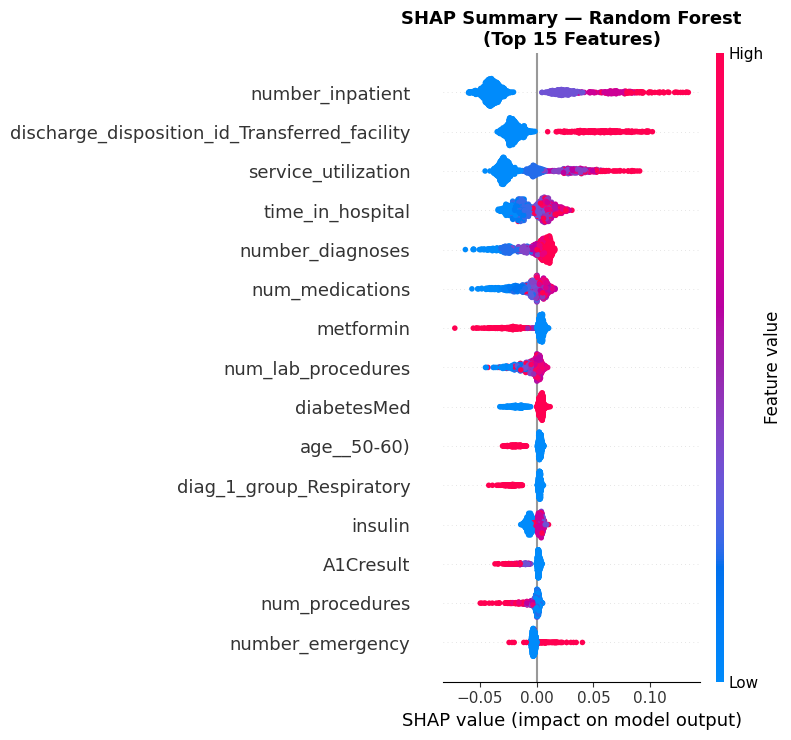

Saved: shap_rf_summary.png


In [81]:
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values_rf_pos,
    X_test_sample,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary — Random Forest\n(Top 15 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_rf_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_rf_summary.png')

In [82]:
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print('SHAP values computed for XGBoost.')
print(f'Shape: {shap_values_xgb.shape}')

SHAP values computed for XGBoost.
Shape: (19899, 72)


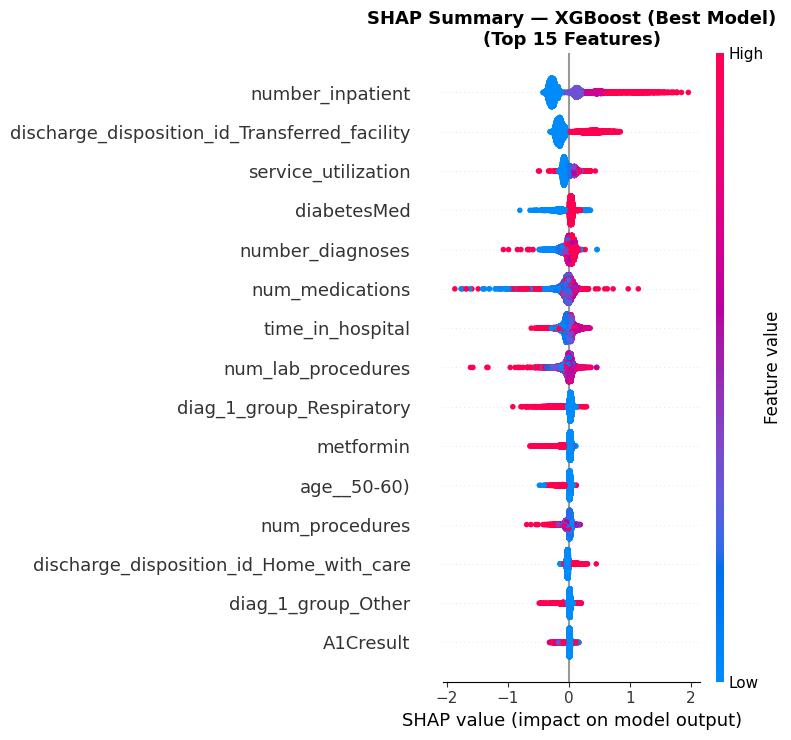

Saved: shap_xgb_summary.png


In [83]:
# XGBoost global summary plot
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Summary — XGBoost (Best Model)\n(Top 15 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_xgb_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_xgb_summary.png')

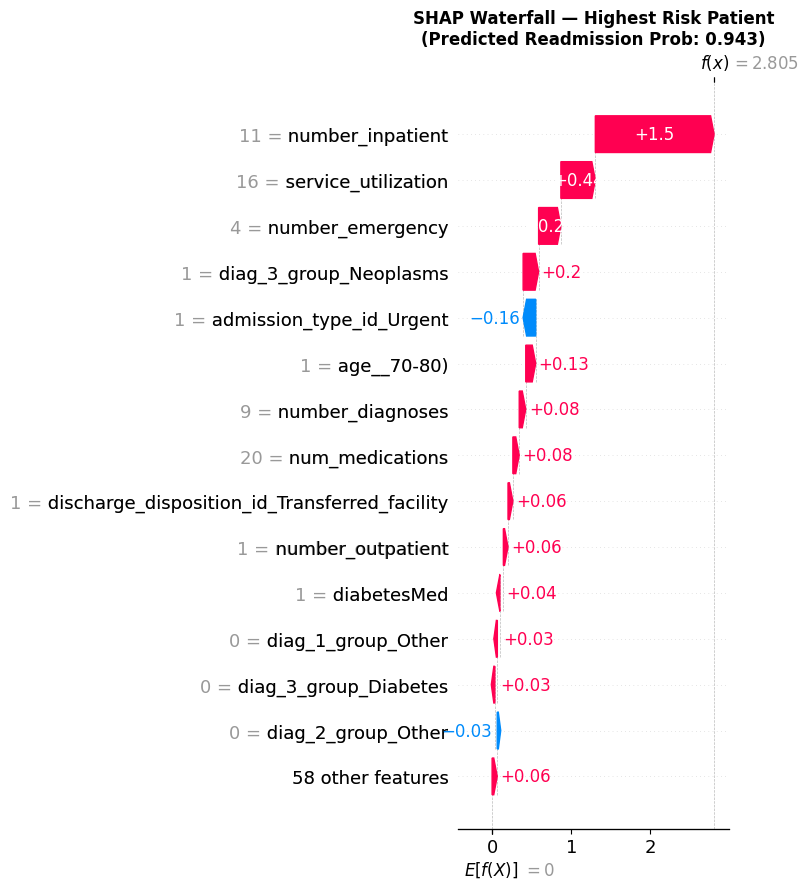

Saved: shap_xgb_waterfall_highrisk.png


In [84]:
# ── Waterfall plot: highest-risk patient ──
# Find the patient the model is most confident will be readmitted
proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(proba_xgb)   # index of patient with highest predicted risk

shap.plots.waterfall(
    shap.Explanation(
        values      = shap_values_xgb[high_risk_idx],
        base_values = explainer_xgb.expected_value,
        data        = X_test.iloc[high_risk_idx],
        feature_names = X_test.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title(f'SHAP Waterfall — Highest Risk Patient\n(Predicted Readmission Prob: {proba_xgb[high_risk_idx]:.3f})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_xgb_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_xgb_waterfall_highrisk.png')

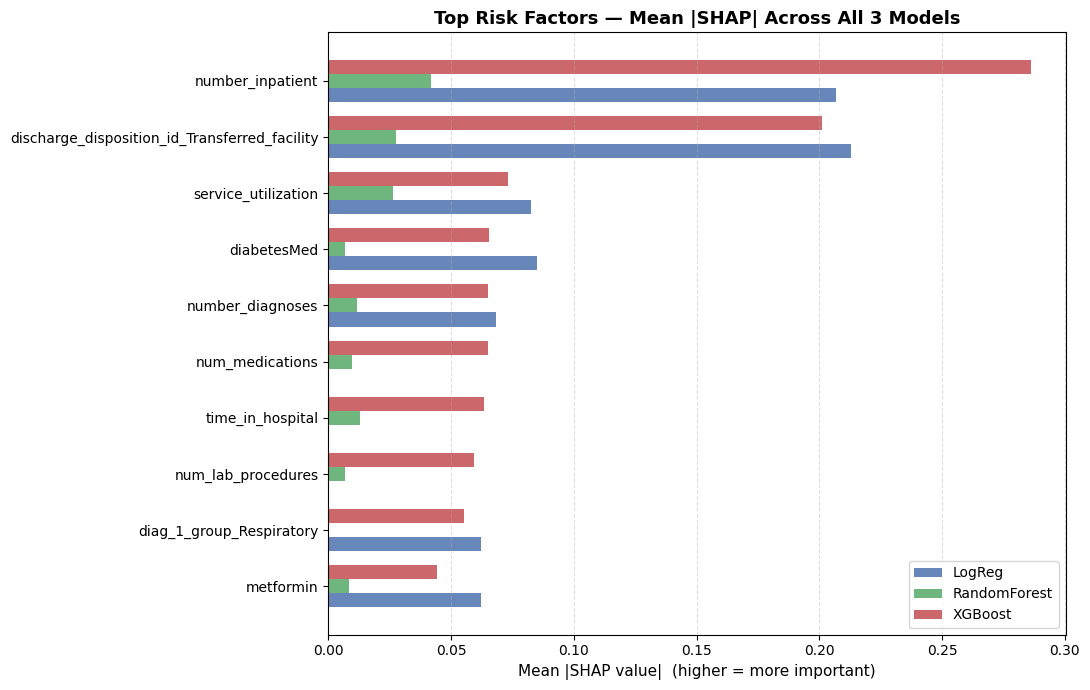

Saved: shap_comparison_all_models.png

Top 10 features by XGBoost SHAP importance:
                                               XGBoost
number_inpatient                                0.2861
discharge_disposition_id_Transferred_facility   0.2011
service_utilization                             0.0732
diabetesMed                                     0.0653
number_diagnoses                                0.0652
num_medications                                 0.0650
time_in_hospital                                0.0634
num_lab_procedures                              0.0591
diag_1_group_Respiratory                        0.0552
metformin                                       0.0443


In [85]:
# Mean absolute SHAP value per feature = global importance
TOP_N = 10

def top_shap_features(shap_vals, feature_names, n=TOP_N):
    # Ensure shap_vals is 2D (num_samples, num_features)
    if shap_vals.ndim == 3 and shap_vals.shape[2] > 1:
        # If it's (num_samples, num_features, num_classes), take class 1
        shap_vals = shap_vals[:, :, 1]

    mean_abs = np.abs(shap_vals).mean(axis=0)
    idx      = np.argsort(mean_abs)[::-1][:n]
    return pd.Series(mean_abs[idx], index=np.array(feature_names)[idx])

# LR uses all test rows (scaled), RF used 1000-row sample, XGB uses all test rows
imp_lr  = top_shap_features(shap_values_lr,      X_test.columns.tolist())
imp_rf  = top_shap_features(shap_values_rf_pos,  X_test_sample.columns.tolist())
imp_xgb = top_shap_features(shap_values_xgb,     X_test.columns.tolist())

# Union of top features across all models
all_features = list(dict.fromkeys(
    imp_lr.index.tolist() + imp_rf.index.tolist() + imp_xgb.index.tolist()
))

compare_df = pd.DataFrame({
    'LogReg':        [imp_lr.get(f, 0)  for f in all_features],
    'RandomForest':  [imp_rf.get(f, 0)  for f in all_features],
    'XGBoost':       [imp_xgb.get(f, 0) for f in all_features],
}, index=all_features)

# Sort by XGBoost importance
compare_df = compare_df.sort_values('XGBoost', ascending=True).tail(TOP_N)

# ── Plot ──
fig, ax = plt.subplots(figsize=(11, 7))
x      = np.arange(len(compare_df))
width  = 0.25
colors = ['#4C72B0', '#55A868', '#C44E52']

bars = []
for i, (col, color) in enumerate(zip(compare_df.columns, colors)):
    b = ax.barh(x + i * width, compare_df[col], width, label=col, color=color, alpha=0.85)
    bars.append(b)

ax.set_yticks(x + width)
ax.set_yticklabels(compare_df.index, fontsize=10)
ax.set_xlabel('Mean |SHAP value|  (higher = more important)', fontsize=11)
ax.set_title('Top Risk Factors — Mean |SHAP| Across All 3 Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('shap_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_comparison_all_models.png')

print('\nTop 10 features by XGBoost SHAP importance:')
print(compare_df[['XGBoost']].sort_values('XGBoost', ascending=False).round(4))

In [86]:
# ── Extract actual top 5 features from XGBoost SHAP for the report ──
top5_xgb = top_shap_features(shap_values_xgb, X_test.columns.tolist(), n=5)
print('=== TOP 5 RISK FACTORS (XGBoost SHAP) ===')
for rank, (feat, val) in enumerate(top5_xgb.items(), 1):
    print(f'  {rank}. {feat:40s}  mean|SHAP| = {val:.4f}')

# ── Check direction of top features ──
print('\n=== DIRECTION ANALYSIS (positive SHAP = increases readmission risk) ===')
mean_shap = shap_values_xgb.mean(axis=0)
mean_shap_s = pd.Series(mean_shap, index=X_test.columns)
for feat in top5_xgb.index:
    direction = 'INCREASES risk' if mean_shap_s[feat] > 0 else 'DECREASES risk'
    print(f'  {feat:40s}  {direction}  (mean SHAP = {mean_shap_s[feat]:+.4f})')

=== TOP 5 RISK FACTORS (XGBoost SHAP) ===
  1. number_inpatient                          mean|SHAP| = 0.2861
  2. discharge_disposition_id_Transferred_facility  mean|SHAP| = 0.2011
  3. service_utilization                       mean|SHAP| = 0.0732
  4. diabetesMed                               mean|SHAP| = 0.0653
  5. number_diagnoses                          mean|SHAP| = 0.0652

=== DIRECTION ANALYSIS (positive SHAP = increases readmission risk) ===
  number_inpatient                          DECREASES risk  (mean SHAP = -0.0668)
  discharge_disposition_id_Transferred_facility  DECREASES risk  (mean SHAP = -0.0371)
  service_utilization                       DECREASES risk  (mean SHAP = -0.0166)
  diabetesMed                               DECREASES risk  (mean SHAP = -0.0044)
  number_diagnoses                          DECREASES risk  (mean SHAP = -0.0054)
